<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/tabular_data/mushroom_toxicity/%D0%9E%D0%B1%D0%BD%D0%B0%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D0%B5_%D1%8F%D0%B4%D0%BE%D0%B2%D0%B8%D1%82%D1%8B%D1%85_%D0%B3%D1%80%D0%B8%D0%B1%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В качестве практики хотел взять то, что в перспективе может принести пользу. Наткнулся на датасет с информацией о ядовитых и съедобных грибах, и решил сделать нейросеть, которая будет их различать. Используем алгоритм XGBoost. Ниже представлен код программы.

In [ ]:
# Импортируем библиотеки
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from xgboost import XGBClassifier

In [ ]:
# Скачиваем датасет
path = kagglehub.dataset_download("devzohaib/mushroom-edibility-classification")

print("Path to dataset files:", path)
df = pd.read_csv(f'{path}/secondary_data.csv', delimiter=';')

df.head()

100%|██████████| 510k/510k [00:00<00:00, 57.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/devzohaib/mushroom-edibility-classification/versions/1


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [ ]:
# Проверяем на пропущенные значения
print(f"Пропущенные значения:\n{df.isnull().sum()}")
df.shape

Пропущенные значения:
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


(61069, 21)

In [ ]:
# Заметим, что есть признаки, имеющие большое количество пропущенных данных
# Удалим эти колонки
df = df.drop(['gill-spacing', 'stem-root', 'stem-surface', 'veil-type', 'veil-color', 'spore-print-color'], axis = 1)

# Выведем пропущенные значения после удаления колонок
print(f"Пропущенные значения:\n{df.isnull().sum()}")

# Заполняем оставшиеся пропущенные данные наиболее частым значением в соответствующей колонке
for column in df.columns:
    if df[column].isnull().sum() > 0:
        most_frequent = df[column].mode()[0]
        df[column] = df[column].fillna(most_frequent)
        print(f"Заполнили {column} значением: {most_frequent}")

print(f"\nПроверка после заполнения:\n{df.isnull().sum()}")

Пропущенные значения:
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-color                  0
stem-height                 0
stem-width                  0
stem-color                  0
has-ring                    0
ring-type                2471
habitat                     0
season                      0
dtype: int64
Заполнили cap-surface значением: t
Заполнили gill-attachment значением: a
Заполнили ring-type значением: f

Проверка после заполнения:
class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season          

Количество строк по меткам:
class
p    33888
e    27181
Name: count, dtype: int64


<Axes: title={'center': 'Распределение меток в датасете'}, xlabel='Съедобность', ylabel='Кол-во'>

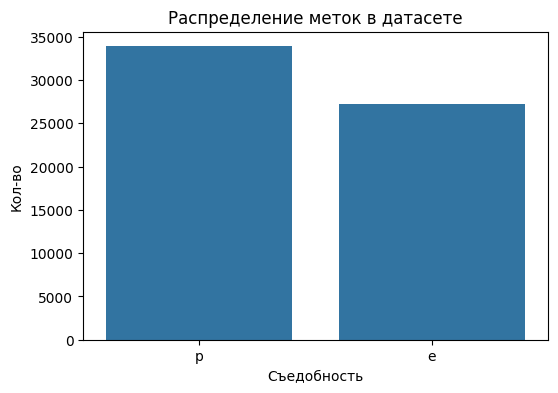

In [ ]:
# Проверим распределение данных
print("Количество строк по меткам:")
print(df['class'].value_counts())
# Визуализируем распределение
plt.figure(figsize = (6,4))
plt.xlabel('Съедобность')
plt.ylabel('Кол-во')
plt.title("Распределение меток в датасете")
sns.countplot(x = "class", data = df)

In [ ]:
class_mapping = {'p': 0, 'e': 1} # Преобразуем метки в числа

y = df['class'].map(class_mapping).values # Метки
X = df.drop('class', axis = 1)  # Признаки

# Переведем данные признаков в числовой вид
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# Нормализуем данные для предотвращения проблем с обучением
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Разделяем данные на train (80%) и test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y  # Сохраняем пропорции классов
)

print("Размеры данных:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Размеры данных:
X_train: (48855, 14), y_train: (48855,)
X_test: (12214, 14), y_test: (12214,)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators = 100,          # Количество деревьев
    max_depth = 6,               # Максимальная глубина дерева
    learning_rate = 0.05,        # Скорость обучения
    subsample = 0.8,             # Доля образцов для каждого дерева
    colsample_bytree = 0.8,      # Доля признаков для каждого дерева
    random_state = 42,           # Для воспроизводимости результатов
    eval_metric = 'logloss',     # Метрика для бинарной классификации
    early_stopping_rounds = 10   # Остановка при отсутствии улучшения
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose = False
)
print("Модель обучена")

Модель обучена


In [ ]:
# Оценка точности модели
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

print("\nОтчет по различным показателям: \n")
print(classification_report(y_test, y_pred, target_names=['Ядовитые', 'Съедобные']))

# Составим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

Точность модели на тестовой выборке: 0.9768

Отчет по различным показателям: 

              precision    recall  f1-score   support

    Ядовитые       0.98      0.98      0.98      6778
   Съедобные       0.97      0.97      0.97      5436

    accuracy                           0.98     12214
   macro avg       0.98      0.98      0.98     12214
weighted avg       0.98      0.98      0.98     12214



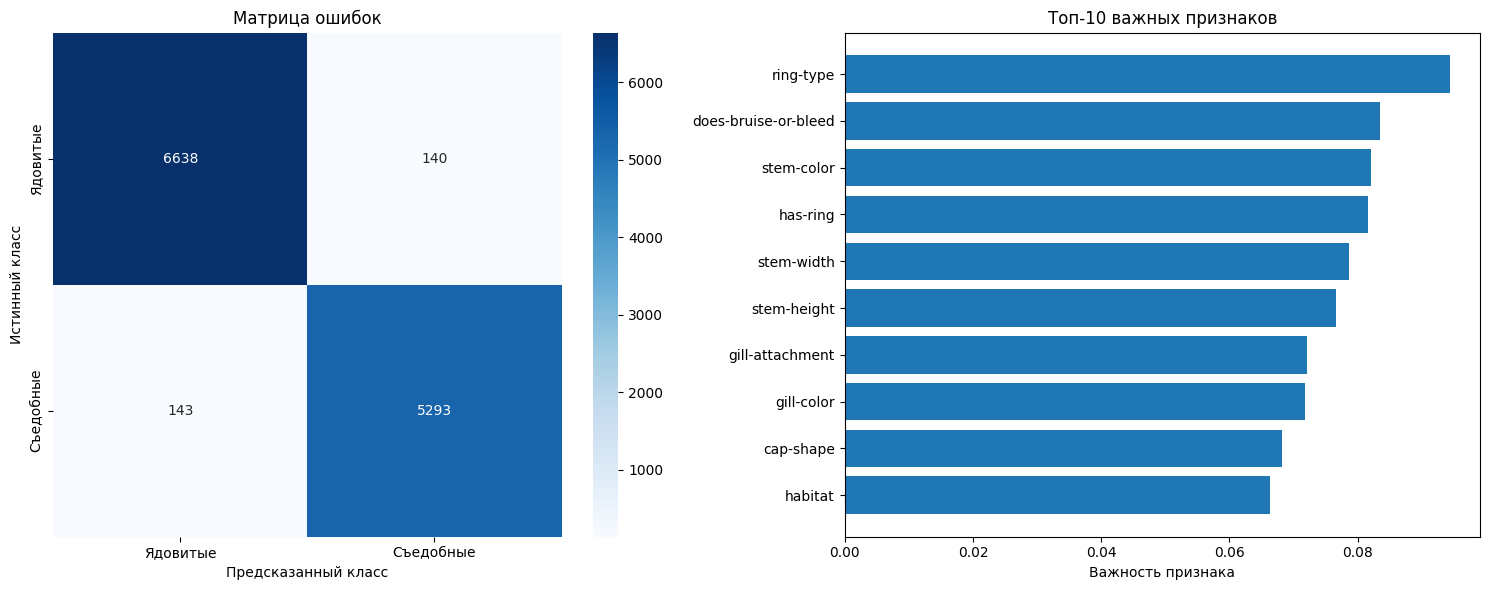

In [ ]:
# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize = (15, 6))

# Матрица ошибок
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Ядовитые', 'Съедобные'],
            yticklabels = ['Ядовитые', 'Съедобные'],
            ax = axes[0])
axes[0].set_title('Матрица ошибок')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending = False)

# Топ-10 важных признаков
top_features = feature_importance.head(10)
axes[1].barh(range(len(top_features)), top_features['importance'])
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['feature'])
axes[1].set_xlabel('Важность признака')
axes[1].set_title('Топ-10 важных признаков')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
#Заметим, что по отдельности признаки имеют примерно одинаковое влияние на результат

###Что дальше?
Поскольку система может повлиять на здоровье человека, рассматривать ее стоит только как советчика.
Из дальнейших шагов вижу следующие:
1. Датасет имел много пропущенных данных. Для улучшения распознавания их можно восстановить.
2. Дополнительное расширение датасета.
3. Создание пользовательского интерфейса и упаковка нейросети в приложение.
4. Особое внимание уделить юридической стороне вопроса по причине, описанной выше.